# Unrotated Surface Code — Effective Distance Fitting (convergence study, **X basis**)

Systematic validation of the **effective distance** $d_e$ for the **unrotated surface code**
($d = 3, 5, 7$), **X-basis** memory, circuit-level depolarizing noise, MWPM (PyMatching) decoding (X-basis cross-check of the Z-basis study).

**Method.** Far below threshold the logical error rate follows a power law
$P_L(p) \approx \alpha\, p^{\,d_e}$, so $d_e$ is the slope of a log–log fit. Ideally $d_e = (d+1)/2$.

**What this notebook does**
- runs each $(d, p)$ with **error-based stopping**: keep sampling until
  `logical_errors >= TARGET_ERRORS` (500). `MAX_SHOTS` is only a **safety guardrail**,
  not the normal stopping condition.
- p grid for the curve: $\{2\mathrm{e}{-3}, 1\mathrm{e}{-3}, 5\mathrm{e}{-4}, 8\mathrm{e}{-5}, 4\mathrm{e}{-5}, 2\mathrm{e}{-5}\}$
- **slope-fit window (3 low-p points)**: $\{8\mathrm{e}{-5}, 4\mathrm{e}{-5}, 2\mathrm{e}{-5}\}$
- a point that fails to reach `TARGET_ERRORS` within `MAX_SHOTS` is flagged
  `max_shots reached` and **excluded from the fit** — we never force a fit on unusable data.

## 1. Imports & repo wiring

In [5]:
%matplotlib inline
import sys, os, time, math, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate repo root (dir with pyproject.toml + lightstim/) so we import THIS repo's lightstim,
# regardless of the cwd the notebook is launched from.
def _find_repo_root(start):
    for d in [start, *start.parents]:
        if (d / "pyproject.toml").exists() and (d / "lightstim").is_dir():
            return d
    raise RuntimeError("repo root not found (need pyproject.toml + lightstim/)")

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import lightstim
from lightstim.simulation.decoder_backend import DecoderConfig, SimulationPipeline
# canonical circuit builder used by the repo's benchmark runner (Handbook-consistent)
from benchmarks.memory.run_memory import build_circuit

print("repo root :", REPO_ROOT)
print("lightstim :", Path(lightstim.__file__).parent)

repo root : /nvme2n1/yuehan_zhang/effective distance/LightStim
lightstim : /nvme2n1/yuehan_zhang/effective distance/LightStim/lightstim


## 2. Configuration

In [6]:
DISTANCES   = [3, 5]
BASIS       = "X"                 # X-basis cross-check (Handbook Table 2 is Z)
NOISE_MODEL = "circuit_level"
DECODER     = "pymatching"        # CPU MWPM

TARGET_ERRORS = 500               # PRIMARY stop: keep sampling until >= this many logical errors
MAX_SHOTS     = int(5e11)         # guardrail ONLY (cap on shots if target is unreachable)
PROBE_SHOTS   = int(1e9)          # shots used to record a point already predicted infeasible
NUM_WORKERS   = 60
BATCH_SIZE    = 5000

P_GRID     = [2e-3, 1e-3, 5e-4, 8e-5, 4e-5, 2e-5]         # full curve
FIT_WINDOW = [8e-5, 4e-5, 2e-5]                      # 3 low-p points used for the slope fit

# Outputs live next to this notebook (pushable).
OUT_DIR     = REPO_ROOT / "notebooks" / "Memory" / "unrotated_effective_distance_results_X_basis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV     = OUT_DIR / "unrotated_effective_distance_raw.csv"
SUMMARY_CSV = OUT_DIR / "unrotated_effective_distance_slope_summary.csv"
FIG_PNG     = OUT_DIR / "unrotated_effective_distance_loglog.png"
FIG_PDF     = OUT_DIR / "unrotated_effective_distance_loglog.pdf"
FIT_LOG     = OUT_DIR / "unrotated_effective_distance_fit.log"

# fit.log: write to file AND echo to the cell output
logger = logging.getLogger("ued"); logger.setLevel(logging.INFO); logger.handlers.clear()
_fh = logging.FileHandler(FIT_LOG, mode="w")
_fh.setFormatter(logging.Formatter("%(asctime)s  %(message)s"))
logger.addHandler(_fh); logger.addHandler(logging.StreamHandler(sys.stdout))
def log(msg): logger.info(msg)

log(f"config: distances={DISTANCES} basis={BASIS} target_errors={TARGET_ERRORS} "
    f"max_shots={MAX_SHOTS:.0e} probe={PROBE_SHOTS:.0e} fit_window={FIT_WINDOW}")

config: distances=[3, 5] basis=X target_errors=500 max_shots=5e+11 probe=1e+09 fit_window=[8e-05, 4e-05, 2e-05]


## 3. Sampling helper — error-based stopping with a feasibility gate

`SimulationPipeline` stops when **either** `max_errors` (our `TARGET_ERRORS`) **or** `max_shots`
is reached, so setting `max_errors=TARGET_ERRORS` gives error-based stopping directly. `stopped_by`
is then just whether we hit the target or the guardrail.

In [7]:
DECODER_CFG = DecoderConfig(name=DECODER, backend="cpu")

def log_sigma(ler, shots):
    # 1-sigma of ln(P_L) from binomial counting statistics; NaN if no errors observed
    if ler is None or ler <= 0 or shots <= 0:
        return float("nan")
    ler = min(max(ler, 1e-18), 1 - 1e-18)
    return math.sqrt((1.0 - ler) / (ler * shots))

def run_point(d, p, cap_shots):
    # Run one (d,p) point: stop at TARGET_ERRORS or cap_shots, whichever first.
    circ, n_data, n_total, k = build_circuit("unrotated_sc", d, p, BASIS, None, NOISE_MODEL)
    pipe = SimulationPipeline(decoder_config=DECODER_CFG,
                              max_shots=int(cap_shots), max_errors=TARGET_ERRORS,
                              batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                              print_progress=False)
    t0 = time.perf_counter()
    st = pipe.run(circ)
    dt = time.perf_counter() - t0
    stopped = "target_errors" if st.errors >= TARGET_ERRORS else "max_shots reached"
    return dict(d=d, p=p, shots=int(st.shots), logical_errors=int(st.errors),
                LER=float(st.logical_error_rate),
                sigma_log_LER=log_sigma(st.logical_error_rate, st.shots),
                stopped_by=stopped, seconds=dt,
                n_data=n_data, n_total=n_total, k=k, cap_shots=int(cap_shots))

def predict_shots_for_target(anchors, p, target):
    # Power-law extrapolation from feasible (p, LER) anchors -> predicted shots for `target` errors.
    x = np.log([pp for pp, _ in anchors]); y = np.log([l for _, l in anchors])
    slope, intercept = np.polyfit(x, y, 1)
    ler_pred = math.exp(intercept + slope * math.log(p))
    return (target / ler_pred) if ler_pred > 0 else float("inf")

## 4. Run the sweep (d = 3, 5, 7;  high p → low p)

In [8]:
rows = []
for d in DISTANCES:
    log(f"--- d={d} (unrotated surface code, basis {BASIS}) ---")
    anchors = []  # feasible (p, LER) for the gate
    for p in sorted(P_GRID, reverse=True):
        if len(anchors) >= 2:
            need = predict_shots_for_target(anchors, p, TARGET_ERRORS)
            infeasible = need > MAX_SHOTS
        else:
            need, infeasible = float("nan"), False
        cap = min(PROBE_SHOTS, MAX_SHOTS) if infeasible else MAX_SHOTS
        r = run_point(d, p, cap)
        rows.append(r)
        if r["stopped_by"] == "target_errors":
            anchors.append((p, r["LER"]))
        pred = "" if math.isnan(need) else (f" pred~{need:.1e} sh" + (" >guardrail->probe" if infeasible else ""))
        log(f"  p={p:.0e}: shots={r['shots']:,} errors={r['logical_errors']} "
            f"LER={r['LER']:.3e} [{r['stopped_by']}] {r['seconds']:.1f}s{pred}")

raw = pd.DataFrame(rows)
log(f"sweep done: {len(raw)} points | total shots={raw.shots.sum():,} | "
    f"total logical errors={raw.logical_errors.sum():,}")

--- d=3 (unrotated surface code, basis X) ---
  p=2e-03: shots=165,000 errors=567 LER=3.436e-03 [target_errors] 1.0s
  p=1e-03: shots=515,000 errors=539 LER=1.047e-03 [target_errors] 0.8s
  p=5e-04: shots=1,865,000 errors=511 LER=2.740e-04 [target_errors] 0.8s pred~1.6e+06 sh
  p=8e-05: shots=31,945,000 errors=502 LER=1.571e-05 [target_errors] 0.9s pred~5.0e+07 sh
  p=4e-05: shots=82,140,000 errors=502 LER=6.112e-06 [target_errors] 0.9s pred~1.1e+08 sh
  p=2e-05: shots=167,875,000 errors=502 LER=2.990e-06 [target_errors] 0.9s pred~2.8e+08 sh
--- d=5 (unrotated surface code, basis X) ---
  p=2e-03: shots=915,000 errors=597 LER=6.525e-04 [target_errors] 0.9s
  p=1e-03: shots=6,430,000 errors=521 LER=8.103e-05 [target_errors] 0.9s
  p=5e-04: shots=47,310,000 errors=501 LER=1.059e-05 [target_errors] 1.4s pred~5.0e+07 sh
  p=8e-05: shots=6,790,535,000 errors=500 LER=7.363e-08 [target_errors] 146.0s pred~1.1e+10 sh
  p=4e-05: shots=38,873,965,000 errors=500 LER=1.286e-08 [target_errors] 799.

## 5. Raw data table

In [9]:
RAW_COLS = ["d", "p", "shots", "logical_errors", "LER", "sigma_log_LER", "stopped_by"]
raw_view = raw[RAW_COLS].sort_values(["d", "p"], ascending=[True, False]).reset_index(drop=True)
raw_view.to_csv(RAW_CSV, index=False)
print(raw_view.to_string(index=False))
print(f"\nsaved raw -> {RAW_CSV}")
raw_view

 d       p        shots  logical_errors          LER  sigma_log_LER    stopped_by
 3 0.00200       165000             567 3.436364e-03       0.041924 target_errors
 3 0.00100       515000             539 1.046602e-03       0.043051 target_errors
 3 0.00050      1865000             511 2.739946e-04       0.044231 target_errors
 3 0.00008     31945000             502 1.571451e-05       0.044632 target_errors
 3 0.00004     82140000             502 6.111517e-06       0.044632 target_errors
 3 0.00002    167875000             502 2.990320e-06       0.044632 target_errors
 5 0.00200       915000             597 6.524590e-04       0.040914 target_errors
 5 0.00100      6430000             521 8.102644e-05       0.043809 target_errors
 5 0.00050     47310000             501 1.058973e-05       0.044676 target_errors
 5 0.00008   6790535000             500 7.363190e-08       0.044721 target_errors
 5 0.00004  38873965000             500 1.286208e-08       0.044721 target_errors
 5 0.00002 19554

,d,p,shots,logical_errors,LER,sigma_log_LER,stopped_by
0,3,0.00200,165000,567,3.436364e-03,0.041924,target_errors
1,3,0.00100,515000,539,1.046602e-03,0.043051,target_errors
2,3,0.00050,1865000,511,2.739946e-04,0.044231,target_errors
3,3,0.00008,31945000,502,1.571451e-05,0.044632,target_errors
4,3,0.00004,82140000,502,6.111517e-06,0.044632,target_errors
5,3,0.00002,167875000,502,2.990320e-06,0.044632,target_errors
6,5,0.00200,915000,597,6.524590e-04,0.040914,target_errors
7,5,0.00100,6430000,521,8.102644e-05,0.043809,target_errors
8,5,0.00050,47310000,501,1.058973e-05,0.044676,target_errors
9,5,0.00008,6790535000,500,7.363190e-08,0.044721,target_errors


## 6. Slope fit over the low-p window {8e-5, 4e-5, 2e-5}

For each $d$ we fit $\log P_L = a + d_e \log p$ using only window points that reached
`TARGET_ERRORS` (reliable LER). Fewer than 3 usable points is reported honestly:
a 2-point fit gives a slope but no standard error; <2 points is "not fittable".

In [10]:
def fit_slope(sub):
    # weighted log-log linear fit; slope == d_e. stderr is NaN for a 2-point fit (0 dof).
    x = np.log(sub["p"].to_numpy()); y = np.log(sub["LER"].to_numpy())
    w = 1.0 / sub["sigma_log_LER"].to_numpy()
    n = len(sub)
    if n < 2:
        return float("nan"), float("nan"), n
    if n == 2:
        return float((y[1]-y[0])/(x[1]-x[0])), float("nan"), n
    coeffs, cov = np.polyfit(x, y, 1, w=w, cov=True)
    return float(coeffs[0]), float(np.sqrt(cov[0, 0])), n

summary_rows = []
log("--- slope fit (window = {" + ", ".join(f"{w:.0e}" for w in sorted(FIT_WINDOW)) + "}) ---")
for d in DISTANCES:
    win = raw[(raw.d == d) & (raw.p.isin(FIT_WINDOW))].copy()
    usable = win[(win.stopped_by == "target_errors") & (win.LER > 0)].sort_values("p")
    missing = [m for m in FIT_WINDOW if all(not np.isclose(up, m) for up in usable.p)]
    ideal = (d + 1) / 2
    d_e, stderr, n_used = fit_slope(usable)
    notes = []
    if missing:
        notes.append("infeasible@p=" + ",".join(f"{m:.0e}" for m in missing))
    if n_used == 2:
        notes.append("2-point fit (stderr undefined)")
    if n_used < 2:
        notes.append("NOT fittable (<2 usable points)")
    if not notes:
        notes.append("full 3-point fit")
    summary_rows.append(dict(
        d=d,
        ideal_eff_distance=ideal,
        p_points_used=";".join(f"{pp:.0e}" for pp in usable.p) if n_used else "(none)",
        fitted_slope_d_e=d_e,
        stderr=stderr,
        total_shots=int(win.shots.sum()),
        total_logical_errors=int(win.logical_errors.sum()),
        notes="; ".join(notes),
    ))
    log(f"  d={d}: ideal={ideal:.1f}  d_e={d_e:.3f} +/- {stderr:.3f}  used={n_used}/3  | {notes}")

summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY_CSV, index=False)
print(summary.to_string(index=False))
print(f"\nsaved summary -> {SUMMARY_CSV}")
summary

--- slope fit (window = {2e-05, 4e-05, 8e-05}) ---
  d=3: ideal=2.0  d_e=1.197 +/- 0.096  used=3/3  | ['full 3-point fit']
  d=5: ideal=3.0  d_e=2.424 +/- 0.054  used=3/3  | ['full 3-point fit']
 d  ideal_eff_distance     p_points_used  fitted_slope_d_e   stderr  total_shots  total_logical_errors            notes
 3                 2.0 2e-05;4e-05;8e-05          1.196863 0.095628    281960000                  1506 full 3-point fit
 5                 3.0 2e-05;4e-05;8e-05          2.423903 0.053869 241206135000                  1500 full 3-point fit

saved summary -> /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_slope_summary.csv


,d,ideal_eff_distance,p_points_used,fitted_slope_d_e,stderr,total_shots,total_logical_errors,notes
0,3,2.0,2e-05;4e-05;8e-05,1.196863,0.095628,281960000,1506,full 3-point fit
1,5,3.0,2e-05;4e-05;8e-05,2.423903,0.053869,241206135000,1500,full 3-point fit


## 7. Log–log plot: LER vs p (fit-window points highlighted, fitted $d_e$ annotated)

saved figure -> /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_loglog.png
             -> /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_loglog.pdf


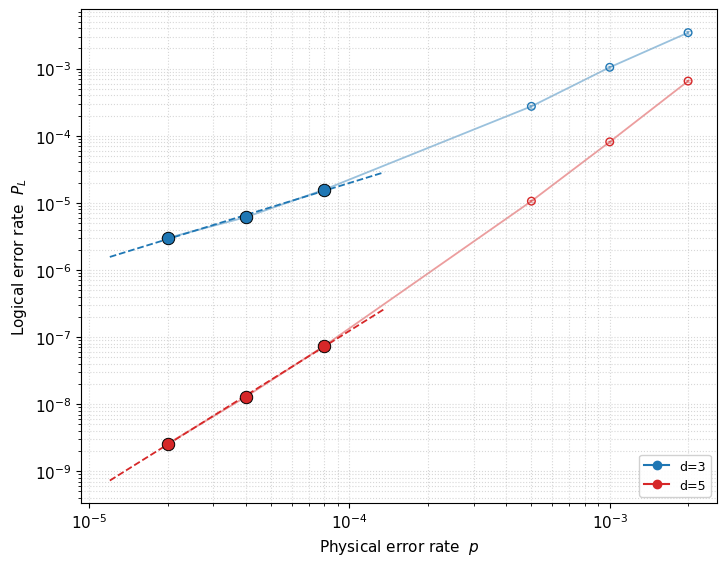

In [11]:
plt.rcParams.update({"font.size": 11})
fig, ax = plt.subplots(figsize=(7.4, 5.8))
COLORS = {3: "#1f77b4", 5: "#d62728", 7: "#2ca02c"}
sm = summary.set_index("d")

for d in DISTANCES:
    sub = raw[(raw.d == d) & (raw.LER > 0)].sort_values("p")
    c = COLORS[d]
    ax.plot(sub.p, sub.LER, "-", color=c, alpha=0.45, lw=1.3, zorder=1)
    ax.errorbar(sub.p, sub.LER, yerr=sub.LER * sub.sigma_log_LER.fillna(0),
                fmt="none", ecolor=c, alpha=0.35, capsize=2, zorder=1)
    nonwin = sub[~sub.p.isin(FIT_WINDOW)]
    ax.scatter(nonwin.p, nonwin.LER, s=30, facecolors="none", edgecolors=c, zorder=2)
    win_ok = sub[(sub.p.isin(FIT_WINDOW)) & (sub.stopped_by == "target_errors")]
    ax.scatter(win_ok.p, win_ok.LER, s=80, color=c, marker="o",
               edgecolors="k", linewidths=0.7, zorder=3)
    win_bad = sub[(sub.p.isin(FIT_WINDOW)) & (sub.stopped_by != "target_errors")]
    ax.scatter(win_bad.p, win_bad.LER, s=80, color=c, marker="x", linewidths=1.8, zorder=3)

    d_e = sm.loc[d, "fitted_slope_d_e"]
    if win_ok.shape[0] >= 2 and np.isfinite(d_e):
        lx = np.log(win_ok.p.to_numpy()); ly = np.log(win_ok.LER.to_numpy())
        inter = ly.mean() - d_e * lx.mean()
        pl = np.array([win_ok.p.min() * 0.6, win_ok.p.max() * 1.7])
        ax.plot(pl, np.exp(inter) * pl ** d_e, "--", color=c, lw=1.3, zorder=2)
    ax.plot([], [], "-", color=c, marker="o", label=f"d={d}")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Physical error rate  $p$")
ax.set_ylabel("Logical error rate  $P_L$")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
fig.tight_layout()
fig.savefig(FIG_PNG, dpi=150, bbox_inches="tight")
fig.savefig(FIG_PDF, bbox_inches="tight")
print(f"saved figure -> {FIG_PNG}")
print(f"             -> {FIG_PDF}")
plt.show()

The blue and ref slope of the three low-\(p\) points on the log-log plot is clearly smaller than that of the three high-\(p\) points, so the effective distance obtained from fitting the low-\(p\) points is also smaller.

## 8. Saved files

In [12]:
NB_FILE = REPO_ROOT / "notebooks" / "Memory" / "unrotated_effective_distance_convergence_X_basis.ipynb"
print("Saved outputs:")
for label, pth in [("notebook", NB_FILE), ("raw csv", RAW_CSV), ("slope summary csv", SUMMARY_CSV),
                   ("log-log png", FIG_PNG), ("log-log pdf", FIG_PDF), ("fit log", FIT_LOG)]:
    mark = "OK" if Path(pth).exists() else "--"
    print(f"  [{mark}] {label:20s} {pth}")

Saved outputs:
  [OK] notebook             /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_convergence_X_basis.ipynb
  [OK] raw csv              /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_raw.csv
  [OK] slope summary csv    /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_slope_summary.csv
  [OK] log-log png          /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_loglog.png
  [OK] log-log pdf          /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_effective_distance_results_X_basis/unrotated_effective_distance_loglog.pdf
  [OK] fit log              /nvme2n1/yuehan_zhang/effective distance/LightStim/notebooks/Memory/unrotated_